In [95]:
import nibabel as nib
import numpy as np
from pathlib import Path
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

TR_DATA_PATH = Path("/media/stabur/Windows_SSD/Users/Mathman/Desktop/brain-seg/archive/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData")

def get_num(num):
    return "0" * (2- math.floor(math.log(num) / math.log(10))) + f"{num}"

def get_filepath(num, mod):
    path = TR_DATA_PATH / (f"BraTS20_Training_" + get_num(num)) / (f"BraTS20_Training_" + get_num(num) + f"_{mod}.nii")
    return path

def print_extra_data(img):
    affine = img.affine
    voxel_size = np.sqrt((affine[:3, :3]**2)).sum(axis=0)
    print(affine)
    print(voxel_size)

def normalized_modality(brain):
    brain_mask = brain > 0
    if brain_mask.sum() == 0:
        print('Edge Case: empty brain')
        return brain
    
    mi = brain[brain_mask].mean()
    std = brain[brain_mask].std() + 1e-8

    brain[brain_mask] = (brain[brain_mask] - mi) / std
    return brain

In [97]:
modalities = ["t1", "t1ce", "t2", "flair", "seg"]
cmap = ListedColormap([
    "black",  #background
    "red", # necrotic
    "green", # edema
    "yellow" # enhancing tumor
])

(240, 240)


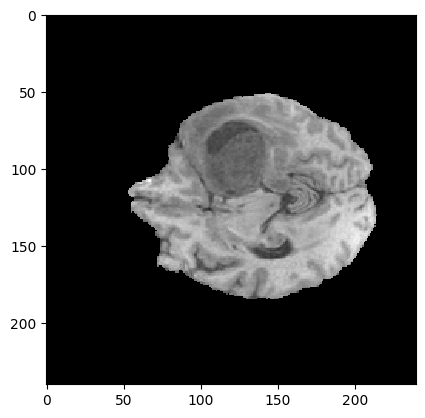

(240, 240)


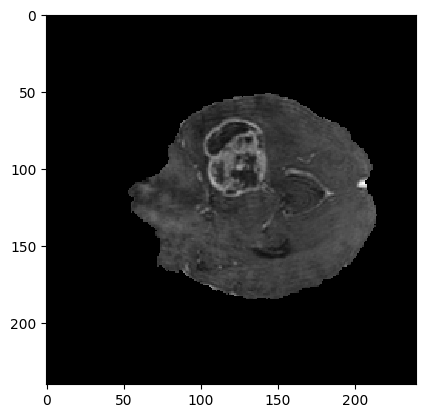

(240, 240)


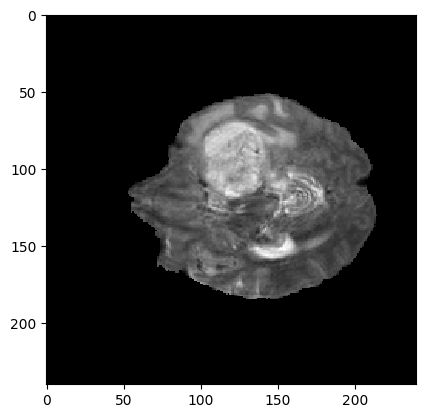

(240, 240)


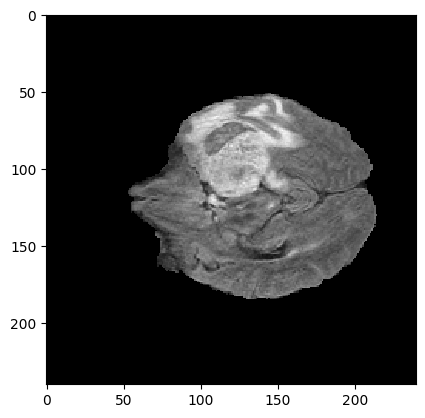

(240, 240)


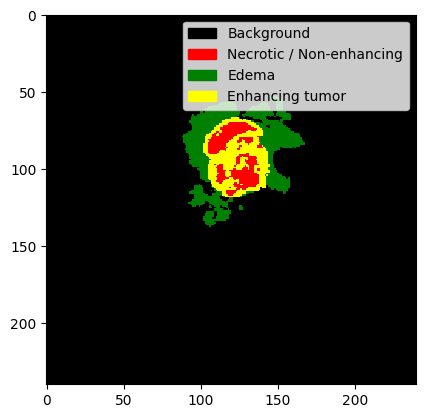

In [ ]:
def visualize_brain(brain_num, slice_num):
    for mod in modalities:
        path = get_filepath(brain_num, mod)
        img = nib.load(path)

        brain = img.get_fdata()
        brain_slice = brain[:, :, slice_num]

        if mod != "seg":
            plt.imshow(brain_slice, cmap="gray", interpolation='nearest')
            plt.show()
            continue
        
        brain_slice[brain_slice == 4] = 3
        patches = [
            mpatches.Patch(color="black", label="Background"),
            mpatches.Patch(color="red", label="Necrotic / Non-enhancing"),
            mpatches.Patch(color="green", label="Edema"),
            mpatches.Patch(color="yellow", label="Enhancing tumor"),
        ]
        plt.imshow(brain_slice, cmap=cmap, interpolation="nearest")
        plt.legend(handles=patches, loc="upper right")
        plt.show()

visualize_brain(1, 59)
